Tue Oct 14 14:41:45 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:3B:00.0 Off |                    0 |
| N/A   48C    P0              26W /  70W |   1167MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

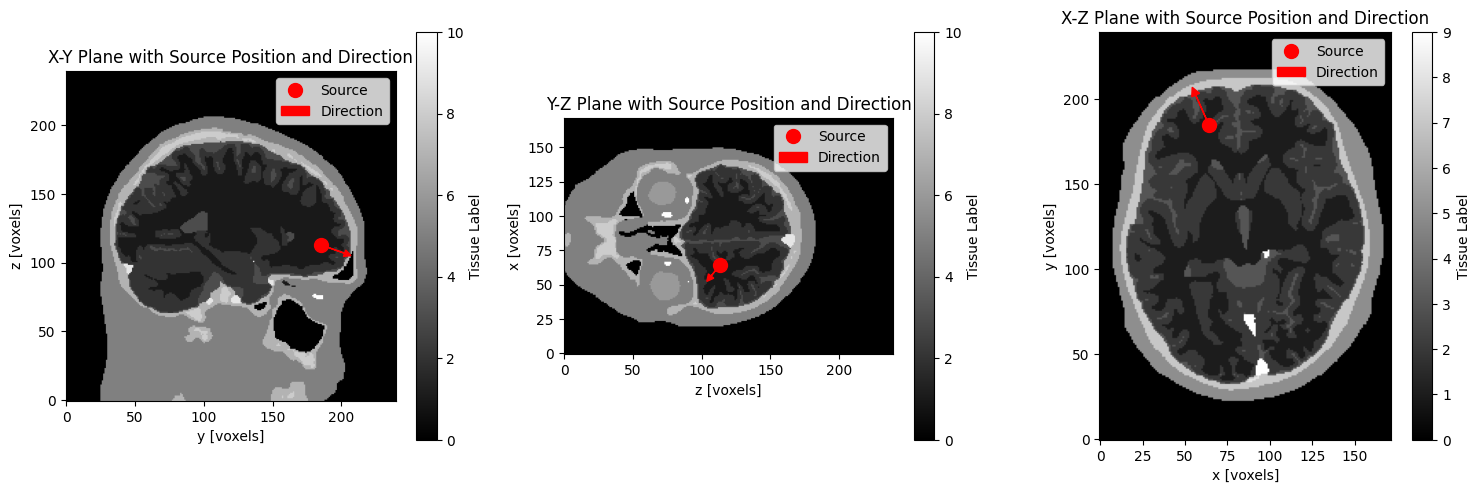

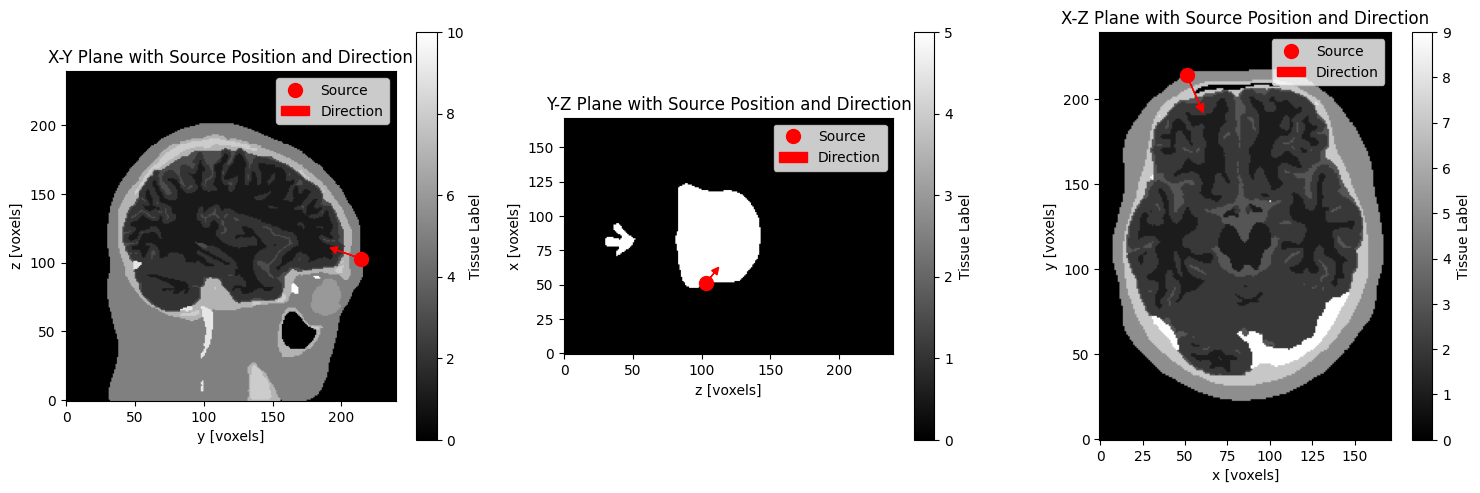

[ 51.4845103  214.25458163 103.44771653] [ 0.38600062 -0.8693321   0.30865065] (172, 240, 240)
Stage 1 completed.
Simple mode outputs already exist in ./results_run_simple
Full mode outputs already exist in ./results_run_full
Done. Both modes have been executed.


In [1]:
# 2.pmcx.run.both
# This script runs the refactored MCX pipeline twice: once in simple mode and once in full mode.
# Outputs are saved to separate directories: ./results_run_simple and ./results_run_full.

import os
import subprocess
from pmcx_utils import run_stage1, run_stage2

# Optional: check GPU status
try:
    subprocess.run(["nvidia-smi"])  # non-fatal if not available
except Exception:
    pass

# Prepare temp data (idempotent)
os.makedirs("pmcx_temp_data", exist_ok=True)
subprocess.run([
    "cp", "-r",
    "/data1/syliu/work25_opensource_pre/m2m_20250614224327",
    "pmcx_temp_data/m2m_20250614224327"
], check=False)

# Parameters
DATA_ROOT = "pmcx_temp_data/m2m_20250614224327"
path = os.path.join(DATA_ROOT, "final_tissues.nii.gz")
subject_csv = os.path.join(DATA_ROOT, "eeg_positions", "EEG10-10_UI_Jurak_2007.csv")
seg_path = None   # Provide for target mode if needed

region_name = "Fp1"
src_dir_mode = "default"  # one of ['default','fixed','target']

# Power/time
p = 250.0  # irradiance (mW)
t = 8.0    # time (mins)
# Optional source overrides
srctype = None        # e.g., 'disk'
srcparam1 = None      # e.g., [12,0,0,0]
srcparam2 = None      # e.g., [0,0,0,0]

# Check inputs
for chk in [path, subject_csv]:
    if not os.path.exists(chk):
        raise FileNotFoundError(f"Path {chk} does not exist")
    else:
        print(f"Path {chk} exists")

# Stage 1
stage1_inputs = {
    'path': path,
    'subject_csv': subject_csv,
    'seg_path': seg_path,
    'region_name': region_name,
    'src_dir_mode': src_dir_mode,
}
stage1_out = run_stage1(stage1_inputs)
print("Stage 1 completed.")

# Build custom source if provided
custom_src = None
if srctype is not None:
    custom_src = {'srctype': srctype}
    if srcparam1 is not None:
        custom_src['srcparam1'] = srcparam1
    if srcparam2 is not None:
        custom_src['srcparam2'] = srcparam2

# Stage 2 - simple
simple_save = "./results_run_simple"
if not os.path.exists(os.path.join(simple_save,"MCX_results_log.nii.gz")):
    stage2_simple = {
        'vol': stage1_out['vol'],
        'src_dir': stage1_out['src_dir'],
        'src_pos': stage1_out['src_pos'],
        'stage_2_mode': 'simple',
        'custom_src': custom_src,
        'save_path': simple_save,
        'p': p,
        't': t,
        'path': path,
    }
    print("Running Stage 2 (simple mode)...")
    stage2_out_simple = run_stage2(stage2_simple)
    print(f"Simple mode outputs saved to: {stage2_out_simple['output_path']}")
else:
    print(f"Simple mode outputs already exist in {simple_save}")

# Stage 2 - full
full_save = "./results_run_full"
if not os.path.exists(os.path.join(full_save,"MCX_results_log.nii.gz")):
    stage2_full = {
        'vol': stage1_out['vol'],
        'src_dir': stage1_out['src_dir'],
        'src_pos': stage1_out['src_pos'],
        'stage_2_mode': 'full',
        'custom_src': custom_src,
        'save_path': full_save,
        'p': p,
        't': t,
        'path': path,
    }
    print("Running Stage 2 (full mode)...")
    stage2_out_full = run_stage2(stage2_full)
    print(f"Full mode outputs saved to: {stage2_out_full['output_path']}")
else:
    print(f"Full mode outputs already exist in {full_save}")

print("Done. Both modes have been executed.")

In [2]:
from rectified_flow_pytorch.rectified_flow import *
import os

# 验证CUDA_HOME设置
print(f"CUDA_HOME环境变量: {os.environ.get('CUDA_HOME', '未设置')}")
if os.path.exists(os.environ.get('CUDA_HOME', '')):
    print("CUDA_HOME路径存在")
    os.system('ls $CUDA_HOME')
else:
    print("警告: CUDA_HOME路径不存在!")

# 验证CUDA是否可用
import torch
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA设备数量: {torch.cuda.device_count()}")
    print(f"当前CUDA设备: {torch.cuda.current_device()}")
    print(f"设备名称: {torch.cuda.get_device_name(torch.cuda.current_device())}")

    # 验证CUDA_VISIBLE_DEVICES设置
    print(f"CUDA_VISIBLE_DEVICES环境变量: {os.environ.get('CUDA_VISIBLE_DEVICES', '未设置')}")



from monai.bundle import ConfigParser
config = ConfigParser()
config.read_config('shiyu_utils/config_maisi3d-rflow.json')
config["autoencoder_def"]["num_splits"]=1
autoencoder =config.get_parsed_content('autoencoder_def',instanitiate=True)
autoencoder.load_state_dict(torch.load("models/autoencoder_epoch273.pt"))
autoencoder.eval()


def test_latent_and_ae():
    latents = sorted(glob.glob(os.path.join(latent_dir,"*.pt")))
    latent = latents[0]
    latent = torch.load(latent,weights_only=False)
    latent = latent.float()
    latent = latent
    latent  = latent / scale 
    latent = latent.float()
    with torch.no_grad(),torch.cuda.amp.autocast(True):
        autoencoder.cuda()
        recon = autoencoder.decode_stage_2_outputs(latent.cuda())
    from shiyu_utils.plot_3d_data import plot_3d_data
    plot_3d_data(recon)
    print(latent.shape,latent.dtype)    
    # =================== 
    latents = sorted(glob.glob(os.path.join(latent_dir,"*.pt")))
    latent = latents[0]
    latent = torch.load(latent,weights_only=False)
    latent = (latent/32).to(torch.float)
    with torch.no_grad(),torch.cuda.amp.autocast(True):
        autoencoder.cuda()
        recon = autoencoder.decode_stage_2_outputs(latent.cuda())
    from shiyu_utils.plot_3d_data import plot_3d_data
    plot_3d_data(recon)
    print(latent.shape,latent.dtype)
    # ==================== 

#test_latent_and_ae()


# In[5]:



from errno import ESTALE
from rectified_flow_pytorch import RectifiedFlow, Unet, Trainer
from monai.networks.nets import DiffusionModelUNet
from torch import nn, pi, cat, stack, from_numpy
from einops import rearrange
class monai_wrapper(torch.nn.Module):
    def __init__(self,model,mean_variance_net=False):
        super().__init__()
        self.model = model
        self.mean_variance_net = mean_variance_net

    def forward(self,x,times,cond=None):
        context = cond 
        timesteps = ((1.- times) * 1000 ).long()
        #for v in[x,context,timesteps]:print(v.shape) if hasattr(v,"shape") else print("v has no shape")
        out= self.model(x,context=context,timesteps=timesteps)
        if self.mean_variance_net:
            mean, log_var = rearrange(out, 'b (c mean_log_var) h w d -> mean_log_var b c h w d', mean_log_var = 2)
            variance = log_var.exp() # variance needs to be positive
            return stack((mean,variance))
        else: 
            return out 


# In[6]:


from rectified_flow_pytorch import RectifiedFlow, Unet, Trainer

monai_model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    num_res_blocks=(2,2,2),
    channels=(64,64,128),
    attention_levels=(False,False,True),
    norm_num_groups=32,
    num_head_channels=64,
    cross_attention_dim=None,
    with_conditioning=False,
    use_flash_attention=True,
    )

model = monai_wrapper(monai_model,mean_variance_net=False)
rectified_flow = RectifiedFlow(model,mean_variance_net=False,data_shape=(4,64,64,64),immiscible=False)



from torch.optim import Adam
from accelerate import Accelerator
from torch.utils.data import DataLoader
from ema_pytorch import EMA

def cycle(dl):
    while True:
        for batch in dl:
            yield batch

from tqdm import tqdm 
from rectified_flow_pytorch import Trainer
class MyTrainer(Trainer):
    def _save_2d_in_png(self,sampled,fname):
        sampled = rearrange(sampled, '(row col) c h w -> c (row h) (col w)', row = self.num_sample_rows)
        sampled.clamp_(0., 1.)

        save_image(sampled, fname)
        return sampled

    def _save_3d_in_png(self,data,fname):
        _,_,h,w,d = data.shape
        hh,ww,dd = h//2,w//2,d//2
        data_xy=data[:,:,hh,:,:]
        data_yz=data[:,:,:,ww,:]
        data_xz=data[:,:,:,:,dd]
        fname_xy=fname.replace(".png","_xy.png")
        fname_yz=fname.replace(".png","_yz.png")
        fname_xz=fname.replace(".png","_xz.png")
        sampled_xy= self._save_2d_in_png(data_xy,fname_xy)
        sampled_yz= self._save_2d_in_png(data_yz,fname_yz)
        sampled_xz= self._save_2d_in_png(data_xz,fname_xz)
        return sampled_xy,sampled_yz,sampled_xz

    def _process_input(self,data):
        noise,cond=None,None
        if isinstance(data,tuple) or isinstance(data,list):
            data,cond=data[0],data[1]
        elif isinstance(data,dict):
            data,noise=data["image"],data["source_image"]
        return data,noise,cond
    
    def sample(self, fname):
        eval_model = default(self.ema_model, self.model)
        dl = cycle(self.dl)
        mock_data = next(dl)
        mock_data,mock_noise,mock_cond =self._process_input(mock_data)
        data_shape = mock_data.shape[1:]
        mock_noise = mock_noise.repeat(self.num_samples//mock_noise.shape[0],1,1,1,1) if hasattr(mock_noise,"shape") else None
        mock_cond = mock_cond.repeat(self.num_samples//mock_cond.shape[0],1,1) if hasattr(mock_cond,"shape") else None
        additional_sample_kwargs = dict()
        if isinstance(eval_model.model, RectifiedFlow):
            additional_sample_kwargs.update(temperature = self.sample_temperature)
            # additional_sample_kwargs.update(noise = mock_noise)
            # additional_sample_kwargs.update(cond = mock_cond)

        with torch.no_grad():
            sampled = eval_model.sample(
                batch_size = self.num_samples,
                data_shape = data_shape,
                noise = mock_noise,
                cond = mock_cond, 
                **additional_sample_kwargs
            )
            global autoencoder
            autoencoder = autoencoder.to(trainer.accelerator.device)
            sampled_collect=[]
            with torch.cuda.amp.autocast(True):
                for sample_per_batch in tqdm(sampled):
                    sample_per_batch = autoencoder.decode_stage_2_outputs(sample_per_batch[None,...]/0.25)
                    sampled_collect.append(sample_per_batch)
                sampled = torch.cat(sampled_collect,dim=0)
            #sample_output = self._save_3d_in_png(sampled,fname)

            mock_data_collect=[]
            with torch.cuda.amp.autocast(True):
                for sample_per_batch in tqdm(mock_data):
                    sample_per_batch = autoencoder.decode_stage_2_outputs(sample_per_batch[None,...]/0.25)
                    mock_data_collect.append(sample_per_batch)
                mock_data = torch.cat(mock_data_collect,dim=0)
                self._save_3d_in_png(mock_data,fname.replace(".png","_tar.png"))
            mock_noise_collect=[]
            if mock_noise is not None:
                with torch.cuda.amp.autocast(True):
                    for sample_per_batch in tqdm(mock_noise):
                        sample_per_batch = autoencoder.decode_stage_2_outputs(sample_per_batch[None,...]/0.25)
                        mock_noise_collect.append(sample_per_batch)
                    mock_noise = torch.cat(mock_noise_collect,dim=0)
                self._save_3d_in_png(mock_noise,fname.replace(".png","_src.png"))
                return {
                    "input":mock_noise,
                    "target":mock_data,
                    "gen":sampled,
                }
            else:
                return {
                    "gen":sampled,
                }
    def forward(self):

        dl = cycle(self.dl)

        for ind in range(self.num_train_steps):
            step = ind + 1

            self.model.train()

            data = next(dl)

            data,noise,cond=self._process_input(data)
            if self.return_loss_breakdown:
                loss, loss_breakdown = self.model(data,noise=noise,cond=cond, return_loss_breakdown = True)
                self.log(loss_breakdown._asdict(), step = step)
            else:
                loss = self.model(data)

            self.accelerator.print(f'[{step}] loss: {loss.item():.3f}')
            self.accelerator.backward(loss)

            self.accelerator.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)

            self.optimizer.step()
            self.optimizer.zero_grad()

            if getattr(self.model, 'use_consistency', False):
                self.model.ema_model.update()

            if self.is_main and self.use_ema:
                self.ema_model.ema_model.data_shape = self.model.data_shape
                self.ema_model.update()

            self.accelerator.wait_for_everyone()
            if self.is_main:

                if divisible_by(step, self.save_results_every) or step==1: # we want to sample for the first step to debug sample 

                    sampled = self.sample(fname = str(self.results_folder / f'results.{step}.png'))

                    self.log_images(sampled, step = step)

                if divisible_by(step, self.checkpoint_every) or step==1:
                    self.save(f'checkpoint.{step}.pt')

            self.accelerator.wait_for_everyone()

        print('training complete')
trainer = MyTrainer(
    rectified_flow,
    dataset = dataset,
    batch_size=4,
    num_samples=4,
    num_train_steps = 70_000,
    sample_temperature = 1.5,
    checkpoint_every=10000,
    checkpoints_folder="./checkpoints_latent_simple2full",
    results_folder = './results_latent_simple2full',  # samples will be saved periodically to this folder
)

#trainer()

CUDA_HOME环境变量: 未设置
警告: CUDA_HOME路径不存在!
PyTorch版本: 2.4.1+cu121
CUDA是否可用: True
CUDA设备数量: 1
当前CUDA设备: 0
设备名称: Tesla T4
CUDA_VISIBLE_DEVICES环境变量: 0


/tmp/ipykernel_3747553/3546616404.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load("models/autoencoder_epoch273.pt"))


NameError: name 'dataset' is not defined